In [2]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import datasets
import tarfile
import re

from scipy.signal import welch
from tqdm.auto import tqdm

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


# Prepare Data for EDA

In [ ]:
tarfile_path = "dataset/audio_2022_chunk_125.tar.gz"
csv_frdr = "dataset/urban-frdr/inspections_2022.csv"
csv_zenodo = "dataset/zenodo/state_labels.csv"
audiofolder_path = "dataset/urban-frdr/audio_2022_chunk_1"

### Extract chuck

In [5]:
# output_folder = "dataset/urban-frdr/audio_2022_chunk_125"
# with tarfile.open(tarfile_path,"r:gz") as tar:
#     tar.extractall(path=output_folder)

### checking status

In [30]:
df_frdr = pd.read_csv(csv_frdr)
target= df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
print(target[['Date', 'Tag number', 'Category', 'Queen status']])

                                 Date  Tag number        Category Queen status
17   2022-08-24 20:30:15.427454+00:00        3627          varroa   queenright
31   2022-07-11 20:23:05.641387+00:00        3692     hive status    queenless
32   2022-07-11 20:23:05.641387+00:00        3692    hive grading    queenless
33   2022-07-11 20:23:05.641387+00:00        3692  frames of bees    queenless
34   2022-07-19 21:32:34.257822+00:00        3692     hive status    queenless
35   2022-07-19 21:32:34.257822+00:00        3692    hive grading    queenless
44   2022-08-24 20:16:33.633384+00:00        3692          varroa   queenright
71   2022-08-24 20:53:05.475343+00:00        3691          varroa   queenright
77   2022-09-30 21:47:53.014515+00:00        3691          varroa   queenright
98   2022-08-24 21:11:39.506501+00:00        3628          varroa   queenright
105  2022-09-30 21:29:31.817886+00:00        3628          varroa   queenright
108  2022-06-02 17:13:07.060900+00:00        3693   

### check status on downloaded chuck

In [ ]:
file_list = os.listdir(audiofolder_path)
print(file_list)

['01-02-2022_01h00_HIVE-6.wav', '01-02-2022_07h30_HIVE-3691.wav', '01-02-2022_08h30_HIVE-6.wav', '01-02-2022_15h15_HIVE-3629.wav', '01-02-2022_21h45_HIVE-3631.wav', '01-04-2022_00h30_HIVE-3629.wav', '01-04-2022_07h30_HIVE-3629.wav', '01-04-2022_12h00_HIVE-3629.wav', '01-08-2022_09h45_HIVE-3692.wav', '01-08-2022_14h30_HIVE-3627.wav', '01-08-2022_22h30_HIVE-3627.wav', '01-09-2022_00h15_HIVE-6.wav', '01-09-2022_04h00_HIVE-6.wav', '01-09-2022_06h15_HIVE-3631.wav', '01-09-2022_19h45_HIVE-3631.wav', '01-09-2022_21h00_HIVE-6.wav', '01-10-2022_01h15_HIVE-3631.wav', '01-10-2022_02h00_HIVE-6.wav', '01-10-2022_17h15_HIVE-3631.wav', '01-10-2022_19h00_HIVE-6.wav', '01-10-2022_20h15_HIVE-3693.wav', '01-11-2022_01h15_HIVE-6.wav', '01-11-2022_05h00_HIVE-3629.wav', '01-11-2022_05h00_HIVE-3631.wav', '01-11-2022_13h45_HIVE-3640.wav', '01-11-2022_19h15_HIVE-3690.wav', '01-11-2022_19h30_HIVE-3693.wav', '01-11-2022_21h15_HIVE-3690.wav', '01-11-2022_21h30_HIVE-3693.wav', '01-11-2022_22h45_HIVE-3690.wav', '01

In [71]:
all_files = ['01-02-2022_01h00_HIVE-6.wav', '01-02-2022_07h30_HIVE-3691.wav', '01-02-2022_08h30_HIVE-6.wav', '01-02-2022_15h15_HIVE-3629.wav', '01-02-2022_21h45_HIVE-3631.wav', '01-04-2022_00h30_HIVE-3629.wav', '01-04-2022_07h30_HIVE-3629.wav', '01-04-2022_12h00_HIVE-3629.wav', '01-08-2022_09h45_HIVE-3692.wav', '01-08-2022_14h30_HIVE-3627.wav', '01-08-2022_22h30_HIVE-3627.wav', '01-09-2022_00h15_HIVE-6.wav', '01-09-2022_04h00_HIVE-6.wav', '01-09-2022_06h15_HIVE-3631.wav', '01-09-2022_19h45_HIVE-3631.wav', '01-09-2022_21h00_HIVE-6.wav', '01-10-2022_01h15_HIVE-3631.wav', '01-10-2022_02h00_HIVE-6.wav', '01-10-2022_17h15_HIVE-3631.wav', '01-10-2022_19h00_HIVE-6.wav', '01-10-2022_20h15_HIVE-3693.wav', '01-11-2022_01h15_HIVE-6.wav', '01-11-2022_05h00_HIVE-3629.wav', '01-11-2022_05h00_HIVE-3631.wav', '01-11-2022_13h45_HIVE-3640.wav', '01-11-2022_19h15_HIVE-3690.wav', '01-11-2022_19h30_HIVE-3693.wav', '01-11-2022_21h15_HIVE-3690.wav', '01-11-2022_21h30_HIVE-3693.wav', '01-11-2022_22h45_HIVE-3690.wav', '01-12-2022_01h30_HIVE-6.wav', '01-12-2022_03h15_HIVE-3640.wav', '01-12-2022_20h45_HIVE-3691.wav', '01-12-2022_21h00_HIVE-3628.wav', '01-12-2022_21h45_HIVE-3691.wav', '02-02-2022_01h30_HIVE-3691.wav', '02-02-2022_02h30_HIVE-3640.wav', '02-02-2022_06h15_HIVE-3628.wav', '02-02-2022_07h45_HIVE-3628.wav', '02-02-2022_11h30_HIVE-6.wav', '02-02-2022_12h30_HIVE-3640.wav', '02-02-2022_13h30_HIVE-6.wav', '02-02-2022_14h30_HIVE-3640.wav', '02-02-2022_19h15_HIVE-3631.wav', '02-02-2022_22h30_HIVE-3640.wav', '02-06-2022_12h45_HIVE-3631.wav', '02-06-2022_13h15_HIVE-3631.wav', '02-06-2022_15h15_HIVE-3692.wav', '02-06-2022_15h45_HIVE-3631.wav', '02-06-2022_20h00_HIVE-3693.wav', '02-08-2022_00h45_HIVE-3692.wav', '02-08-2022_08h30_HIVE-3627.wav', '02-10-2022_07h30_HIVE-3690.wav', '02-10-2022_08h15_HIVE-3693.wav', '02-10-2022_16h15_HIVE-3693.wav', '02-11-2022_03h00_HIVE-3692.wav', '02-11-2022_05h45_HIVE-3629.wav', '02-11-2022_06h15_HIVE-3690.wav', '02-11-2022_07h45_HIVE-3629.wav', '02-11-2022_09h00_HIVE-3693.wav', '02-11-2022_18h15_HIVE-3629.wav', '02-11-2022_20h45_HIVE-3629.wav', '02-11-2022_21h30_HIVE-3693.wav', '02-11-2022_23h00_HIVE-3640.wav', '02-12-2022_21h45_HIVE-3640.wav', '02-12-2022_23h30_HIVE-6.wav', '03-02-2022_00h00_HIVE-6.wav', '03-02-2022_05h15_HIVE-3692.wav', '03-02-2022_11h15_HIVE-3631.wav', '03-02-2022_11h45_HIVE-3629.wav', '03-02-2022_11h45_HIVE-3631.wav', '03-02-2022_22h30_HIVE-6.wav', '03-02-2022_23h30_HIVE-3640.wav', '03-04-2022_08h45_HIVE-3640.wav', '03-04-2022_11h15_HIVE-3640.wav', '03-05-2022_07h30_HIVE-6.wav', '03-05-2022_09h30_HIVE-6.wav', '03-05-2022_12h00_HIVE-6.wav', '03-06-2022_07h15_HIVE-3692.wav', '03-06-2022_08h15_HIVE-3691.wav', '03-06-2022_10h00_HIVE-3627.wav', '03-06-2022_10h30_HIVE-3693.wav', '03-06-2022_11h00_HIVE-6.wav', '03-06-2022_14h00_HIVE-3693.wav', '03-06-2022_14h30_HIVE-3627.wav', '03-06-2022_15h00_HIVE-3640.wav', '03-06-2022_15h15_HIVE-3692.wav', '03-06-2022_18h30_HIVE-3627.wav', '03-06-2022_22h15_HIVE-3631.wav', '03-08-2022_06h45_HIVE-3692.wav', '03-08-2022_09h15_HIVE-3692.wav', '03-08-2022_10h00_HIVE-3627.wav', '03-08-2022_14h00_HIVE-3627.wav', '03-08-2022_14h45_HIVE-3693.wav', '03-08-2022_16h00_HIVE-3690.wav', '03-08-2022_22h45_HIVE-3628.wav', '03-09-2022_00h00_HIVE-6.wav', '03-09-2022_01h30_HIVE-6.wav', '03-09-2022_06h30_HIVE-3628.wav', '03-09-2022_08h00_HIVE-3693.wav', '03-09-2022_08h30_HIVE-6.wav', '03-09-2022_09h30_HIVE-3628.wav', '03-09-2022_13h30_HIVE-6.wav', '03-09-2022_14h15_HIVE-3690.wav', '03-09-2022_14h45_HIVE-3691.wav', '03-09-2022_15h45_HIVE-3690.wav', '03-10-2022_05h15_HIVE-3629.wav', '03-10-2022_09h30_HIVE-3631.wav', '03-10-2022_13h30_HIVE-3631.wav', '03-10-2022_15h15_HIVE-6.wav', '03-10-2022_16h30_HIVE-3631.wav', '03-11-2022_19h15_HIVE-3627.wav', '03-11-2022_22h00_HIVE-3629.wav', '03-11-2022_23h45_HIVE-3640.wav', '03-12-2022_08h45_HIVE-3640.wav', '03-12-2022_18h30_HIVE-3628.wav', '03-12-2022_22h30_HIVE-3640.wav', '04-02-2022_13h15_HIVE-3628.wav', '04-02-2022_14h00_HIVE-3691.wav', '04-02-2022_15h00_HIVE-3691.wav', '04-02-2022_15h30_HIVE-6.wav', '04-06-2022_05h30_HIVE-3628.wav', '04-06-2022_06h45_HIVE-3631.wav', '04-06-2022_08h00_HIVE-3640.wav', '04-06-2022_13h30_HIVE-3640.wav', '04-06-2022_18h00_HIVE-3640.wav', '04-06-2022_19h45_HIVE-3629.wav', '04-06-2022_20h15_HIVE-3691.wav', '04-06-2022_21h15_HIVE-3690.wav', '04-06-2022_22h15_HIVE-3690.wav', '04-07-2022_21h30_HIVE-3691.wav', '04-07-2022_22h15_HIVE-3693.wav', '04-07-2022_23h00_HIVE-3690.wav', '04-08-2022_02h00_HIVE-3692.wav', '04-08-2022_08h00_HIVE-3693.wav', '04-08-2022_11h45_HIVE-3627.wav', '04-08-2022_16h15_HIVE-3627.wav', '04-08-2022_18h15_HIVE-3690.wav', '04-08-2022_18h45_HIVE-3691.wav', '04-08-2022_19h45_HIVE-3627.wav', '04-09-2022_03h00_HIVE-3628.wav', '04-09-2022_19h45_HIVE-3690.wav', '04-09-2022_20h15_HIVE-3691.wav', '04-10-2022_13h00_HIVE-3629.wav', '04-10-2022_19h15_HIVE-6.wav', '04-10-2022_19h45_HIVE-6.wav', '04-10-2022_20h45_HIVE-3640.wav', '04-10-2022_23h45_HIVE-3640.wav', '04-11-2022_00h15_HIVE-3690.wav', '04-11-2022_03h15_HIVE-3690.wav', '04-11-2022_04h00_HIVE-3629.wav', '04-11-2022_04h45_HIVE-3640.wav', '04-11-2022_15h45_HIVE-3640.wav', '04-11-2022_16h45_HIVE-3627.wav', '04-11-2022_18h45_HIVE-3627.wav', '04-11-2022_23h30_HIVE-3629.wav', '04-12-2022_00h30_HIVE-3640.wav', '04-12-2022_02h30_HIVE-6.wav', '04-12-2022_04h45_HIVE-3628.wav', '05-01-2022_12h45_HIVE-3631.wav', '05-01-2022_13h15_HIVE-3627.wav', '05-01-2022_13h45_HIVE-3690.wav', '05-01-2022_23h30_HIVE-6.wav', '05-02-2022_00h00_HIVE-6.wav', '05-02-2022_02h30_HIVE-6.wav', '05-02-2022_03h15_HIVE-3628.wav', '05-02-2022_04h45_HIVE-3629.wav', '05-02-2022_05h15_HIVE-3631.wav', '05-02-2022_06h00_HIVE-3640.wav', '05-02-2022_08h00_HIVE-6.wav', '05-02-2022_18h15_HIVE-3629.wav', '05-02-2022_18h45_HIVE-3631.wav', '05-02-2022_19h00_HIVE-3628.wav', '05-02-2022_19h45_HIVE-3631.wav', '05-02-2022_20h15_HIVE-3691.wav', '05-04-2022_02h15_HIVE-3640.wav', '05-04-2022_04h00_HIVE-3629.wav', '05-04-2022_06h30_HIVE-3629.wav', '05-04-2022_21h30_HIVE-3629.wav', '05-04-2022_22h30_HIVE-3629.wav', '05-05-2022_00h15_HIVE-3631.wav', '05-05-2022_02h45_HIVE-3631.wav', '05-06-2022_05h15_HIVE-3690.wav', '05-06-2022_05h45_HIVE-3692.wav', '05-06-2022_06h15_HIVE-3691.wav', '05-06-2022_07h00_HIVE-3627.wav', '05-06-2022_11h00_HIVE-3628.wav', '05-06-2022_11h30_HIVE-3627.wav', '05-06-2022_19h15_HIVE-3692.wav', '05-07-2022_10h30_HIVE-3691.wav', '05-07-2022_10h45_HIVE-3640.wav', '05-07-2022_11h30_HIVE-3691.wav', '05-07-2022_13h00_HIVE-3690.wav', '05-07-2022_13h45_HIVE-3693.wav', '05-08-2022_01h30_HIVE-3628.wav', '05-08-2022_03h45_HIVE-3690.wav', '05-08-2022_04h15_HIVE-3691.wav', '05-08-2022_05h15_HIVE-3627.wav', '05-08-2022_07h45_HIVE-3691.wav', '05-08-2022_10h45_HIVE-3690.wav', '05-08-2022_13h45_HIVE-3690.wav', '05-09-2022_03h30_HIVE-3693.wav', '05-09-2022_06h45_HIVE-3690.wav', '05-09-2022_07h15_HIVE-3691.wav', '05-09-2022_11h45_HIVE-3631.wav', '05-09-2022_12h30_HIVE-3693.wav', '05-10-2022_04h15_HIVE-6.wav', '05-10-2022_05h15_HIVE-3640.wav', '05-10-2022_08h30_HIVE-3629.wav', '05-10-2022_14h00_HIVE-3629.wav', '05-11-2022_19h45_HIVE-3627.wav', '05-12-2022_00h15_HIVE-3690.wav', '05-12-2022_00h45_HIVE-3628.wav', '05-12-2022_02h00_HIVE-3627.wav', '05-12-2022_02h15_HIVE-3631.wav', '05-12-2022_04h00_HIVE-3640.wav', '05-12-2022_18h15_HIVE-3629.wav', '05-12-2022_18h30_HIVE-3693.wav', '05-12-2022_21h30_HIVE-6.wav', '06-01-2022_03h30_HIVE-3693.wav', '06-01-2022_04h00_HIVE-3692.wav', '06-01-2022_05h15_HIVE-3627.wav', '06-01-2022_05h30_HIVE-6.wav', '06-01-2022_06h15_HIVE-3631.wav', '06-01-2022_07h45_HIVE-3627.wav', '06-01-2022_08h15_HIVE-3690.wav', '06-01-2022_08h45_HIVE-3631.wav', '06-01-2022_09h15_HIVE-3691.wav', '06-01-2022_15h30_HIVE-3692.wav', '06-01-2022_16h00_HIVE-6.wav', '06-01-2022_17h45_HIVE-3691.wav', '06-01-2022_22h15_HIVE-3631.wav', '06-02-2022_00h30_HIVE-6.wav', '06-02-2022_02h15_HIVE-3629.wav', '06-02-2022_06h30_HIVE-6.wav', '06-02-2022_09h00_HIVE-6.wav', '06-02-2022_10h15_HIVE-3631.wav', '06-02-2022_12h00_HIVE-6.wav', '06-02-2022_12h45_HIVE-3629.wav', '06-02-2022_21h45_HIVE-3629.wav', '06-04-2022_03h45_HIVE-3640.wav', '06-05-2022_11h45_HIVE-3631.wav', '06-05-2022_13h30_HIVE-6.wav', '06-05-2022_14h30_HIVE-6.wav', '06-06-2022_04h00_HIVE-3640.wav', '06-06-2022_13h15_HIVE-3629.wav', '06-06-2022_20h00_HIVE-3640.wav', '06-06-2022_23h45_HIVE-3692.wav', '06-07-2022_00h45_HIVE-3640.wav', '06-07-2022_10h00_HIVE-3629.wav', '06-07-2022_20h30_HIVE-3629.wav', '06-07-2022_21h15_HIVE-3693.wav', '06-08-2022_02h45_HIVE-3691.wav', '06-08-2022_08h45_HIVE-3691.wav', '06-08-2022_12h15_HIVE-3690.wav', '06-08-2022_20h15_HIVE-3690.wav', '06-09-2022_08h45_HIVE-6.wav', '06-09-2022_09h30_HIVE-3631.wav', '06-09-2022_10h15_HIVE-6.wav', '06-10-2022_02h00_HIVE-3631.wav', '06-10-2022_02h45_HIVE-3640.wav', '06-10-2022_17h45_HIVE-3640.wav', '06-10-2022_19h30_HIVE-3629.wav', '06-11-2022_03h15_HIVE-3627.wav', '06-11-2022_04h30_HIVE-3629.wav', '06-11-2022_16h00_HIVE-3692.wav', '06-11-2022_18h45_HIVE-3640.wav', '06-11-2022_20h00_HIVE-3692.wav', '06-11-2022_21h30_HIVE-3629.wav', '06-12-2022_01h15_HIVE-3692.wav', '06-12-2022_02h00_HIVE-3627.wav', '06-12-2022_03h45_HIVE-3628.wav', '06-12-2022_04h45_HIVE-3631.wav', '06-12-2022_05h00_HIVE-6.wav', '06-12-2022_06h00_HIVE-3693.wav', '06-12-2022_11h45_HIVE-3631.wav', '06-12-2022_12h45_HIVE-3640.wav', '06-12-2022_13h30_HIVE-3627.wav', '06-12-2022_14h45_HIVE-3692.wav', '06-12-2022_15h15_HIVE-3640.wav', '06-12-2022_16h00_HIVE-3627.wav', '07-01-2022_04h45_HIVE-3691.wav', '07-01-2022_14h45_HIVE-3631.wav', '07-01-2022_18h45_HIVE-3631.wav', '07-01-2022_19h15_HIVE-3691.wav', '07-01-2022_21h00_HIVE-3692.wav', '07-01-2022_21h30_HIVE-3628.wav', '07-01-2022_23h00_HIVE-3628.wav', '07-02-2022_10h00_HIVE-3640.wav', '07-02-2022_11h00_HIVE-3628.wav', '07-02-2022_18h00_HIVE-3640.wav', '07-02-2022_19h30_HIVE-3640.wav', '07-04-2022_11h30_HIVE-3629.wav', '07-04-2022_13h15_HIVE-3640.wav', '07-04-2022_15h45_HIVE-3640.wav', '07-05-2022_11h45_HIVE-3631.wav', '07-05-2022_13h30_HIVE-6.wav', '07-05-2022_16h00_HIVE-6.wav', '07-05-2022_20h00_HIVE-6.wav', '07-05-2022_23h30_HIVE-6.wav', '07-06-2022_00h15_HIVE-3691.wav', '07-06-2022_01h00_HIVE-3627.wav', '07-06-2022_02h15_HIVE-3629.wav', '07-06-2022_10h45_HIVE-3692.wav', '07-06-2022_11h15_HIVE-3691.wav', '07-06-2022_11h45_HIVE-3690.wav', '07-06-2022_12h15_HIVE-3629.wav', '07-06-2022_13h30_HIVE-3640.wav', '07-06-2022_14h00_HIVE-3628.wav', '07-06-2022_14h30_HIVE-3693.wav', '07-06-2022_19h30_HIVE-3628.wav', '07-06-2022_20h00_HIVE-3627.wav', '07-07-2022_02h45_HIVE-3640.wav', '07-07-2022_09h00_HIVE-3690.wav', '07-07-2022_10h00_HIVE-3629.wav', '07-07-2022_18h15_HIVE-3693.wav', '07-07-2022_23h15_HIVE-3640.wav', '07-08-2022_00h30_HIVE-3693.wav', '07-08-2022_23h45_HIVE-3628.wav', '07-09-2022_01h00_HIVE-3631.wav', '07-09-2022_14h30_HIVE-3631.wav', '07-09-2022_16h15_HIVE-6.wav', '07-10-2022_13h00_HIVE-3690.wav', '07-10-2022_13h45_HIVE-3640.wav', '07-10-2022_15h45_HIVE-3693.wav', '07-10-2022_20h00_HIVE-3631.wav', '07-11-2022_01h45_HIVE-3631.wav', '07-11-2022_02h15_HIVE-3640.wav', '07-11-2022_03h15_HIVE-3627.wav', '07-11-2022_04h00_HIVE-3692.wav', '07-11-2022_09h15_HIVE-3640.wav', '07-11-2022_11h00_HIVE-3628.wav', '07-11-2022_14h15_HIVE-3693.wav', '07-11-2022_17h15_HIVE-3629.wav', '07-11-2022_17h30_HIVE-3692.wav', '07-11-2022_19h00_HIVE-3690.wav', '07-11-2022_19h45_HIVE-3693.wav', '07-11-2022_20h15_HIVE-3629.wav', '07-11-2022_22h15_HIVE-3629.wav', '07-11-2022_22h45_HIVE-3629.wav', '07-12-2022_01h15_HIVE-3628.wav', '07-12-2022_02h00_HIVE-6.wav', '07-12-2022_05h30_HIVE-3627.wav', '07-12-2022_07h45_HIVE-3692.wav', '07-12-2022_08h15_HIVE-3640.wav', '07-12-2022_09h00_HIVE-3627.wav', '07-12-2022_17h45_HIVE-3692.wav', '07-12-2022_18h30_HIVE-3629.wav', '07-12-2022_21h45_HIVE-3631.wav', '07-12-2022_22h15_HIVE-3628.wav', '07-12-2022_23h15_HIVE-3631.wav', '07-12-2022_23h45_HIVE-3631.wav', '08-01-2022_00h15_HIVE-3627.wav', '08-01-2022_17h00_HIVE-6.wav', '08-01-2022_18h15_HIVE-3690.wav', '08-01-2022_23h00_HIVE-3628.wav', '08-01-2022_23h45_HIVE-3690.wav', '08-02-2022_06h45_HIVE-3629.wav', '08-02-2022_08h00_HIVE-3628.wav', '08-06-2022_09h45_HIVE-3691.wav', '08-06-2022_10h30_HIVE-3640.wav', '08-06-2022_14h15_HIVE-3691.wav', '08-06-2022_14h45_HIVE-3692.wav', '08-06-2022_19h15_HIVE-3691.wav', '08-06-2022_20h45_HIVE-3629.wav', '08-07-2022_01h45_HIVE-3640.wav', '08-07-2022_02h30_HIVE-3690.wav', '08-07-2022_03h45_HIVE-3693.wav', '08-08-2022_05h15_HIVE-3628.wav', '08-08-2022_19h00_HIVE-3693.wav', '08-09-2022_04h30_HIVE-3631.wav', '08-10-2022_05h00_HIVE-3631.wav', '08-10-2022_12h15_HIVE-3693.wav', '08-10-2022_14h30_HIVE-3629.wav', '08-10-2022_15h15_HIVE-3640.wav', '08-10-2022_16h15_HIVE-3640.wav', '08-10-2022_17h30_HIVE-3631.wav', '08-10-2022_19h15_HIVE-3631.wav', '08-10-2022_22h00_HIVE-3629.wav', '08-11-2022_00h00_HIVE-6.wav', '08-11-2022_00h30_HIVE-6.wav', '08-11-2022_01h00_HIVE-6.wav', '08-11-2022_05h30_HIVE-3628.wav', '08-11-2022_09h45_HIVE-3631.wav', '08-11-2022_10h15_HIVE-3691.wav', '08-11-2022_14h45_HIVE-3693.wav', '08-11-2022_16h00_HIVE-6.wav', '08-11-2022_16h30_HIVE-6.wav', '08-11-2022_19h45_HIVE-3640.wav', '08-11-2022_22h30_HIVE-3690.wav', '08-12-2022_00h30_HIVE-3629.wav', '08-12-2022_00h45_HIVE-3692.wav', '08-12-2022_02h45_HIVE-3628.wav', '08-12-2022_04h00_HIVE-3691.wav', '08-12-2022_06h00_HIVE-3691.wav', '08-12-2022_07h30_HIVE-6.wav', '08-12-2022_17h15_HIVE-3640.wav', '08-12-2022_22h00_HIVE-3627.wav', '08-12-2022_22h45_HIVE-3692.wav', '08-12-2022_23h45_HIVE-3640.wav', '09-01-2022_00h15_HIVE-3691.wav', '09-01-2022_01h15_HIVE-3631.wav', '09-01-2022_07h45_HIVE-3690.wav', '09-01-2022_08h15_HIVE-3691.wav', '09-01-2022_09h15_HIVE-3631.wav', '09-01-2022_13h15_HIVE-3690.wav', '09-01-2022_13h45_HIVE-3691.wav', '09-01-2022_23h00_HIVE-3693.wav', '09-01-2022_23h30_HIVE-6.wav', '09-02-2022_03h00_HIVE-3640.wav', '09-02-2022_16h30_HIVE-3628.wav', '09-06-2022_07h15_HIVE-3692.wav', '09-07-2022_04h15_HIVE-3693.wav', '09-07-2022_05h15_HIVE-3640.wav', '09-08-2022_21h45_HIVE-3690.wav', '09-08-2022_23h00_HIVE-3693.wav', '09-09-2022_02h00_HIVE-3631.wav', '09-09-2022_08h45_HIVE-6.wav', '09-09-2022_10h45_HIVE-6.wav', '09-09-2022_14h15_HIVE-6.wav', '09-09-2022_20h30_HIVE-3631.wav', '09-10-2022_03h45_HIVE-3628.wav', '09-11-2022_06h00_HIVE-3640.wav', '09-11-2022_07h30_HIVE-3628.wav', '09-11-2022_07h45_HIVE-3693.wav', '09-11-2022_09h15_HIVE-3631.wav', '09-11-2022_12h45_HIVE-3629.wav', '09-11-2022_14h45_HIVE-3629.wav', '09-11-2022_15h45_HIVE-3629.wav', '09-11-2022_22h15_HIVE-3631.wav', '09-12-2022_09h00_HIVE-3629.wav', '10-01-2022_02h15_HIVE-3690.wav', '10-01-2022_03h00_HIVE-3691.wav', '10-01-2022_11h45_HIVE-3631.wav', '10-01-2022_19h45_HIVE-3690.wav', '10-01-2022_21h00_HIVE-3691.wav', '10-02-2022_01h45_HIVE-3691.wav', '10-02-2022_04h45_HIVE-3629.wav', '10-02-2022_05h45_HIVE-3629.wav', '10-02-2022_11h00_HIVE-3640.wav', '10-02-2022_21h30_HIVE-3640.wav', '10-02-2022_22h15_HIVE-3629.wav', '10-03-2022_19h00_HIVE-3690.wav', '10-03-2022_21h30_HIVE-3631.wav', '10-06-2022_05h30_HIVE-3640.wav', '10-06-2022_07h30_HIVE-3640.wav', '10-06-2022_10h00_HIVE-3640.wav', '10-07-2022_03h15_HIVE-3693.wav', '10-07-2022_04h15_HIVE-3693.wav', '10-07-2022_05h15_HIVE-3640.wav', '10-07-2022_10h00_HIVE-3690.wav', '10-07-2022_20h30_HIVE-3690.wav', '10-07-2022_23h45_HIVE-3693.wav', '10-08-2022_07h30_HIVE-3693.wav', '10-08-2022_18h15_HIVE-3690.wav', '10-08-2022_20h30_HIVE-3693.wav', '10-11-2022_00h00_HIVE-3640.wav', '10-11-2022_08h00_HIVE-3628.wav', '10-11-2022_08h15_HIVE-3693.wav', '10-11-2022_11h30_HIVE-6.wav', '10-11-2022_18h45_HIVE-3693.wav', '10-11-2022_19h15_HIVE-3691.wav', '10-12-2022_01h00_HIVE-3629.wav', '10-12-2022_02h30_HIVE-3629.wav', '10-12-2022_05h15_HIVE-3692.wav', '10-12-2022_06h30_HIVE-3627.wav', '10-12-2022_16h45_HIVE-3640.wav', '11-01-2022_00h00_HIVE-6.wav', '11-01-2022_03h30_HIVE-3691.wav', '11-01-2022_06h45_HIVE-3628.wav', '11-02-2022_05h30_HIVE-3640.wav', '11-02-2022_06h45_HIVE-3629.wav', '11-02-2022_07h30_HIVE-3628.wav', '11-03-2022_05h45_HIVE-3693.wav', '11-03-2022_09h00_HIVE-3631.wav', '11-03-2022_10h15_HIVE-3693.wav', '11-03-2022_14h00_HIVE-3631.wav', '11-03-2022_14h45_HIVE-6.wav', '11-03-2022_18h30_HIVE-3631.wav', '11-03-2022_22h00_HIVE-3690.wav', '11-03-2022_23h45_HIVE-6.wav', '11-06-2022_06h00_HIVE-3640.wav', '11-06-2022_07h45_HIVE-3629.wav', '11-06-2022_10h15_HIVE-3629.wav', '11-06-2022_19h15_HIVE-3640.wav', '11-06-2022_23h15_HIVE-3640.wav', '11-07-2022_00h30_HIVE-3629.wav', '11-07-2022_12h00_HIVE-6.wav', '11-08-2022_00h30_HIVE-3631.wav', '11-08-2022_08h15_HIVE-3690.wav', '11-08-2022_14h30_HIVE-3631.wav', '11-08-2022_15h45_HIVE-3690.wav', '11-08-2022_18h00_HIVE-3631.wav', '11-08-2022_18h45_HIVE-6.wav', '11-11-2022_09h00_HIVE-3628.wav', '11-11-2022_10h30_HIVE-6.wav', '11-11-2022_11h00_HIVE-3691.wav', '11-11-2022_15h30_HIVE-3627.wav', '11-11-2022_18h15_HIVE-3692.wav', '11-11-2022_18h45_HIVE-3693.wav', '11-11-2022_19h15_HIVE-3693.wav', '11-11-2022_19h45_HIVE-3629.wav', '11-12-2022_01h15_HIVE-3640.wav', '11-12-2022_02h45_HIVE-3692.wav', '11-12-2022_05h30_HIVE-3629.wav', '11-12-2022_06h45_HIVE-3692.wav', '11-12-2022_07h30_HIVE-3627.wav', '11-12-2022_08h45_HIVE-3640.wav', '11-12-2022_19h30_HIVE-3627.wav', '11-12-2022_23h30_HIVE-3627.wav', '12-01-2022_00h30_HIVE-3691.wav', '12-01-2022_08h15_HIVE-3628.wav', '12-01-2022_08h45_HIVE-3631.wav', '12-01-2022_09h30_HIVE-6.wav', '12-01-2022_13h15_HIVE-3631.wav', '12-01-2022_13h45_HIVE-3690.wav', '12-01-2022_16h00_HIVE-6.wav', '12-01-2022_17h15_HIVE-3690.wav', '12-01-2022_19h15_HIVE-3628.wav', '12-01-2022_20h00_HIVE-3693.wav', '12-01-2022_21h15_HIVE-3690.wav', '12-01-2022_22h30_HIVE-3693.wav', '12-04-2022_08h30_HIVE-3693.wav', '12-04-2022_09h15_HIVE-3690.wav', '12-04-2022_16h45_HIVE-3690.wav', '12-04-2022_23h15_HIVE-3690.wav', '12-07-2022_08h15_HIVE-3629.wav', '12-07-2022_09h00_HIVE-3640.wav', '12-07-2022_09h30_HIVE-3640.wav', '12-07-2022_21h30_HIVE-3629.wav', '12-08-2022_02h00_HIVE-3631.wav', '12-08-2022_03h30_HIVE-3631.wav', '12-08-2022_04h45_HIVE-3690.wav', '12-08-2022_17h30_HIVE-3693.wav', '12-11-2022_00h00_HIVE-3690.wav', '12-11-2022_01h15_HIVE-3693.wav', '12-11-2022_01h45_HIVE-3631.wav', '12-11-2022_05h00_HIVE-3627.wav', '12-11-2022_06h15_HIVE-3693.wav', '12-11-2022_07h15_HIVE-3692.wav', '12-11-2022_09h00_HIVE-3627.wav', '12-11-2022_10h15_HIVE-3628.wav', '12-11-2022_10h45_HIVE-3631.wav', '12-11-2022_11h15_HIVE-3631.wav', '12-11-2022_11h30_HIVE-3691.wav', '12-11-2022_12h00_HIVE-3691.wav', '12-12-2022_03h15_HIVE-3692.wav', '12-12-2022_06h00_HIVE-3629.wav', '12-12-2022_09h15_HIVE-3692.wav', '12-12-2022_10h15_HIVE-3640.wav', '12-12-2022_11h00_HIVE-3629.wav', '12-12-2022_14h00_HIVE-3690.wav', '12-12-2022_15h00_HIVE-3691.wav', '13-01-2022_01h45_HIVE-3628.wav', '13-01-2022_10h00_HIVE-3693.wav', '13-01-2022_11h00_HIVE-3691.wav', '13-01-2022_19h30_HIVE-3693.wav', '13-02-2022_03h30_HIVE-3628.wav', '13-02-2022_05h15_HIVE-3691.wav', '13-03-2022_01h15_HIVE-6.wav', '13-03-2022_07h30_HIVE-3631.wav', '13-03-2022_09h15_HIVE-6.wav', '13-04-2022_01h45_HIVE-3640.wav', '13-04-2022_02h15_HIVE-3690.wav', '13-04-2022_03h00_HIVE-3693.wav', '13-04-2022_12h15_HIVE-6.wav', '13-04-2022_13h15_HIVE-3640.wav', '13-04-2022_14h30_HIVE-3629.wav', '13-04-2022_15h00_HIVE-3631.wav', '13-04-2022_17h45_HIVE-3690.wav', '13-04-2022_18h15_HIVE-6.wav', '13-04-2022_22h45_HIVE-3690.wav', '13-04-2022_23h30_HIVE-3693.wav', '13-07-2022_11h30_HIVE-3629.wav', '13-07-2022_13h15_HIVE-3640.wav', '13-07-2022_23h15_HIVE-3640.wav', '13-08-2022_13h15_HIVE-3690.wav', '13-11-2022_02h30_HIVE-3627.wav', '13-11-2022_04h30_HIVE-3629.wav', '13-11-2022_06h45_HIVE-3640.wav', '13-11-2022_11h30_HIVE-3629.wav', '13-12-2022_06h30_HIVE-3690.wav', '13-12-2022_07h45_HIVE-3628.wav', '13-12-2022_10h45_HIVE-3628.wav', '13-12-2022_20h45_HIVE-3628.wav', '14-01-2022_10h45_HIVE-3691.wav', '14-01-2022_12h15_HIVE-3690.wav', '14-01-2022_20h00_HIVE-3693.wav', '14-01-2022_21h15_HIVE-3691.wav', '14-04-2022_00h30_HIVE-3631.wav', '14-04-2022_13h15_HIVE-3690.wav', '14-04-2022_13h45_HIVE-6.wav', '14-04-2022_16h30_HIVE-3631.wav', '14-06-2022_11h00_HIVE-3629.wav', '14-06-2022_12h45_HIVE-3640.wav', '14-06-2022_15h15_HIVE-3640.wav', '14-08-2022_12h15_HIVE-3690.wav', '14-08-2022_14h00_HIVE-3693.wav', '14-08-2022_23h30_HIVE-3693.wav', '14-10-2022_18h15_HIVE-3691.wav', '14-11-2022_04h00_HIVE-3629.wav', '14-11-2022_05h15_HIVE-3640.wav', '14-11-2022_19h15_HIVE-3628.wav', '14-11-2022_21h00_HIVE-3631.wav', '14-11-2022_22h15_HIVE-3628.wav', '14-12-2022_09h15_HIVE-3628.wav', '15-02-2022_20h30_HIVE-3628.wav', '15-04-2022_00h15_HIVE-3690.wav', '15-04-2022_01h30_HIVE-3693.wav', '15-04-2022_04h00_HIVE-3631.wav', '15-04-2022_16h45_HIVE-6.wav', '15-04-2022_17h45_HIVE-3640.wav', '15-04-2022_19h00_HIVE-3629.wav', '15-04-2022_23h30_HIVE-3631.wav', '15-06-2022_01h30_HIVE-3629.wav', '15-06-2022_14h45_HIVE-3640.wav', '15-07-2022_03h30_HIVE-3629.wav', '15-07-2022_05h15_HIVE-3640.wav', '15-07-2022_14h00_HIVE-3629.wav', '15-07-2022_15h45_HIVE-3640.wav', '15-07-2022_18h15_HIVE-3640.wav', '15-07-2022_21h00_HIVE-3629.wav', '15-09-2022_16h45_HIVE-3693.wav', '15-09-2022_17h30_HIVE-3691.wav', '15-09-2022_18h15_HIVE-6.wav', '15-09-2022_22h15_HIVE-3628.wav', '15-11-2022_00h30_HIVE-3691.wav', '15-11-2022_01h30_HIVE-3629.wav', '15-11-2022_02h30_HIVE-3629.wav', '15-11-2022_10h00_HIVE-3629.wav', '15-12-2022_02h30_HIVE-3690.wav', '16-01-2022_01h00_HIVE-3693.wav', '16-01-2022_03h15_HIVE-3691.wav', '16-01-2022_16h15_HIVE-3690.wav', '16-01-2022_18h30_HIVE-3693.wav', '16-01-2022_19h45_HIVE-3691.wav', '16-03-2022_15h00_HIVE-3692.wav', '16-03-2022_15h30_HIVE-3693.wav', '16-03-2022_16h30_HIVE-3631.wav', '16-03-2022_20h45_HIVE-3690.wav', '16-03-2022_21h15_HIVE-6.wav', '16-03-2022_23h30_HIVE-3692.wav', '16-04-2022_11h15_HIVE-6.wav', '16-04-2022_13h45_HIVE-3690.wav', '16-04-2022_14h30_HIVE-3693.wav', '16-04-2022_23h00_HIVE-3629.wav', '16-05-2022_17h00_HIVE-3628.wav', '16-05-2022_17h30_HIVE-6.wav', '16-05-2022_18h15_HIVE-3631.wav', '16-06-2022_06h30_HIVE-3631.wav', '16-06-2022_11h00_HIVE-3631.wav', '16-06-2022_12h15_HIVE-6.wav', '16-06-2022_18h45_HIVE-3640.wav', '16-06-2022_19h00_HIVE-3629.wav', '16-06-2022_22h15_HIVE-6.wav', '16-06-2022_23h00_HIVE-3628.wav', '16-06-2022_23h30_HIVE-3628.wav', '16-09-2022_02h30_HIVE-3690.wav', '16-09-2022_03h00_HIVE-3691.wav', '16-09-2022_07h45_HIVE-6.wav', '16-09-2022_08h30_HIVE-3631.wav', '16-09-2022_12h00_HIVE-3631.wav', '16-09-2022_19h30_HIVE-3690.wav', '16-09-2022_20h30_HIVE-3631.wav', '16-11-2022_11h45_HIVE-3628.wav', '16-11-2022_13h00_HIVE-3629.wav', '16-11-2022_17h30_HIVE-3691.wav', '16-12-2022_00h30_HIVE-3690.wav', '16-12-2022_04h15_HIVE-3693.wav', '16-12-2022_14h30_HIVE-3690.wav', '17-01-2022_13h30_HIVE-3693.wav', '17-03-2022_11h15_HIVE-3690.wav', '17-03-2022_16h15_HIVE-3627.wav', '17-03-2022_21h15_HIVE-6.wav', '17-04-2022_10h30_HIVE-3629.wav', '17-04-2022_13h00_HIVE-3631.wav', '17-04-2022_14h00_HIVE-3629.wav', '17-04-2022_15h00_HIVE-3629.wav', '17-04-2022_16h15_HIVE-3640.wav', '17-04-2022_18h45_HIVE-6.wav', '17-05-2022_05h30_HIVE-3628.wav', '17-05-2022_09h00_HIVE-3627.wav', '17-05-2022_09h45_HIVE-3692.wav', '17-05-2022_11h15_HIVE-3692.wav', '17-05-2022_11h45_HIVE-3692.wav', '17-05-2022_13h00_HIVE-3628.wav', '17-05-2022_14h00_HIVE-3628.wav', '17-05-2022_16h30_HIVE-3627.wav', '17-05-2022_21h30_HIVE-3627.wav', '17-06-2022_05h00_HIVE-3627.wav', '17-06-2022_05h30_HIVE-3628.wav', '17-06-2022_06h00_HIVE-3629.wav', '17-06-2022_07h15_HIVE-3640.wav', '17-06-2022_08h00_HIVE-3628.wav', '17-09-2022_17h30_HIVE-3691.wav', '17-09-2022_18h30_HIVE-3631.wav', '17-09-2022_19h45_HIVE-3628.wav', '17-10-2022_00h00_HIVE-3631.wav', '17-10-2022_05h15_HIVE-6.wav', '17-10-2022_07h45_HIVE-6.wav', '17-10-2022_13h00_HIVE-3690.wav', '17-10-2022_15h30_HIVE-3631.wav', '17-10-2022_16h15_HIVE-6.wav', '17-10-2022_17h00_HIVE-3690.wav', '17-10-2022_17h45_HIVE-3691.wav', '17-10-2022_18h30_HIVE-3631.wav', '17-10-2022_22h15_HIVE-3693.wav', '17-11-2022_01h30_HIVE-3629.wav', '17-11-2022_04h15_HIVE-3640.wav', '17-11-2022_05h15_HIVE-3628.wav', '17-11-2022_09h00_HIVE-3629.wav', '17-11-2022_11h00_HIVE-3691.wav', '17-11-2022_20h15_HIVE-3640.wav', '17-12-2022_03h00_HIVE-3690.wav', '18-01-2022_23h15_HIVE-3628.wav', '18-03-2022_08h30_HIVE-3692.wav', '18-03-2022_14h15_HIVE-3627.wav', '18-03-2022_15h00_HIVE-3693.wav', '18-03-2022_16h45_HIVE-3690.wav', '18-03-2022_17h45_HIVE-3690.wav', '18-03-2022_22h30_HIVE-3693.wav', '18-03-2022_23h15_HIVE-3627.wav', '18-04-2022_05h15_HIVE-3640.wav', '18-05-2022_08h00_HIVE-3627.wav', '18-05-2022_18h30_HIVE-3628.wav', '18-05-2022_21h00_HIVE-3628.wav', '18-05-2022_21h30_HIVE-3628.wav', '18-06-2022_08h15_HIVE-3631.wav', '18-06-2022_14h30_HIVE-6.wav', '18-09-2022_09h15_HIVE-3628.wav', '18-09-2022_10h30_HIVE-3631.wav', '18-09-2022_14h30_HIVE-3691.wav', '18-09-2022_18h30_HIVE-3691.wav', '18-10-2022_11h00_HIVE-3690.wav', '18-10-2022_12h15_HIVE-3693.wav', '18-10-2022_14h30_HIVE-3690.wav', '18-10-2022_15h45_HIVE-3693.wav', '18-12-2022_12h45_HIVE-3693.wav', '19-03-2022_00h45_HIVE-6.wav', '19-03-2022_01h45_HIVE-6.wav', '19-03-2022_02h45_HIVE-3627.wav', '19-03-2022_04h45_HIVE-6.wav', '19-03-2022_10h45_HIVE-3690.wav', '19-03-2022_12h30_HIVE-3692.wav', '19-03-2022_16h15_HIVE-6.wav', '19-03-2022_23h15_HIVE-3627.wav', '19-03-2022_23h45_HIVE-3690.wav', '19-04-2022_01h15_HIVE-6.wav', '19-04-2022_02h00_HIVE-3629.wav', '19-04-2022_02h45_HIVE-3690.wav', '19-04-2022_07h30_HIVE-3631.wav', '19-04-2022_09h00_HIVE-3631.wav', '19-04-2022_10h00_HIVE-3629.wav', '19-04-2022_11h15_HIVE-3640.wav', '19-04-2022_12h00_HIVE-3631.wav', '19-04-2022_13h15_HIVE-6.wav', '19-04-2022_22h45_HIVE-3640.wav', '19-05-2022_00h15_HIVE-3691.wav', '19-06-2022_03h30_HIVE-6.wav', '19-06-2022_04h45_HIVE-3692.wav', '19-06-2022_06h30_HIVE-3640.wav', '19-06-2022_07h00_HIVE-6.wav', '19-06-2022_09h45_HIVE-3692.wav', '19-06-2022_22h15_HIVE-3629.wav', '19-06-2022_23h00_HIVE-6.wav', '19-06-2022_23h30_HIVE-6.wav', '19-08-2022_19h00_HIVE-3631.wav', '19-08-2022_20h45_HIVE-6.wav', '19-09-2022_03h45_HIVE-3628.wav', '19-09-2022_05h45_HIVE-6.wav', '19-09-2022_13h30_HIVE-3631.wav', '19-09-2022_14h45_HIVE-3628.wav', '19-09-2022_22h00_HIVE-3631.wav', '19-10-2022_09h30_HIVE-3628.wav', '19-10-2022_16h30_HIVE-3690.wav', '19-10-2022_17h30_HIVE-3628.wav', '19-10-2022_19h00_HIVE-3690.wav', '19-10-2022_20h00_HIVE-3628.wav', '19-10-2022_22h00_HIVE-3628.wav', '19-11-2022_01h45_HIVE-3640.wav', '19-11-2022_12h15_HIVE-3640.wav', '19-11-2022_17h45_HIVE-3640.wav', '20-03-2022_04h15_HIVE-3627.wav', '20-03-2022_06h45_HIVE-3690.wav', '20-03-2022_07h30_HIVE-3693.wav', '20-03-2022_18h30_HIVE-3631.wav', '20-04-2022_19h15_HIVE-3640.wav', '20-04-2022_20h30_HIVE-3693.wav', '20-04-2022_21h15_HIVE-3640.wav', '20-05-2022_14h15_HIVE-3691.wav', '20-05-2022_18h00_HIVE-3628.wav', '20-05-2022_18h30_HIVE-3690.wav', '20-05-2022_21h15_HIVE-6.wav', '20-06-2022_19h15_HIVE-3640.wav', '20-08-2022_03h30_HIVE-3631.wav', '20-08-2022_06h00_HIVE-3631.wav', '20-08-2022_12h15_HIVE-6.wav', '20-08-2022_17h30_HIVE-3631.wav', '20-09-2022_03h00_HIVE-3631.wav', '20-09-2022_03h45_HIVE-6.wav', '20-09-2022_05h00_HIVE-3691.wav', '20-10-2022_03h15_HIVE-3691.wav', '20-10-2022_21h00_HIVE-3628.wav', '21-03-2022_04h15_HIVE-3627.wav', '21-03-2022_04h30_HIVE-3693.wav', '21-03-2022_08h45_HIVE-6.wav', '21-03-2022_11h15_HIVE-3690.wav', '21-03-2022_14h30_HIVE-3693.wav', '21-05-2022_00h15_HIVE-3691.wav', '21-05-2022_01h15_HIVE-6.wav', '21-05-2022_02h00_HIVE-3628.wav', '21-05-2022_04h00_HIVE-3628.wav', '21-05-2022_06h15_HIVE-3693.wav', '21-05-2022_07h00_HIVE-3690.wav', '21-05-2022_09h30_HIVE-3631.wav', '21-05-2022_10h00_HIVE-3628.wav', '21-05-2022_13h00_HIVE-3631.wav', '21-06-2022_04h15_HIVE-3691.wav', '21-06-2022_05h15_HIVE-3640.wav', '21-06-2022_09h15_HIVE-3691.wav', '21-06-2022_13h45_HIVE-3691.wav', '21-06-2022_15h00_HIVE-3629.wav', '21-06-2022_17h00_HIVE-3628.wav', '21-06-2022_18h15_HIVE-3640.wav', '21-06-2022_21h15_HIVE-3640.wav', '21-06-2022_22h00_HIVE-3629.wav', '21-09-2022_00h30_HIVE-3691.wav', '21-09-2022_02h00_HIVE-3691.wav', '21-09-2022_03h00_HIVE-3631.wav', '21-09-2022_04h15_HIVE-3628.wav', '21-09-2022_07h00_HIVE-3691.wav', '21-09-2022_08h30_HIVE-3631.wav', '21-09-2022_17h00_HIVE-3631.wav', '21-09-2022_18h15_HIVE-3628.wav', '21-10-2022_05h00_HIVE-3690.wav', '21-10-2022_08h00_HIVE-3628.wav', '21-10-2022_08h45_HIVE-3693.wav', '21-10-2022_11h15_HIVE-3693.wav', '21-10-2022_12h30_HIVE-3690.wav', '21-10-2022_15h30_HIVE-3628.wav', '21-10-2022_16h45_HIVE-3691.wav', '21-10-2022_17h30_HIVE-3690.wav', '21-10-2022_20h45_HIVE-3691.wav', '22-03-2022_00h00_HIVE-3631.wav', '22-03-2022_00h30_HIVE-3692.wav', '22-03-2022_02h30_HIVE-3692.wav', '22-03-2022_20h30_HIVE-3693.wav', '22-03-2022_21h30_HIVE-3631.wav', '22-03-2022_22h00_HIVE-3692.wav', '22-05-2022_05h00_HIVE-3631.wav', '22-05-2022_13h30_HIVE-3690.wav', '22-05-2022_14h00_HIVE-3690.wav', '22-05-2022_14h45_HIVE-6.wav', '22-05-2022_16h00_HIVE-3690.wav', '22-06-2022_03h00_HIVE-3628.wav', '22-06-2022_13h30_HIVE-3628.wav', '22-06-2022_14h15_HIVE-3691.wav', '22-06-2022_15h30_HIVE-3629.wav', '22-06-2022_22h30_HIVE-3629.wav', '22-08-2022_18h30_HIVE-3631.wav', '22-08-2022_19h00_HIVE-3693.wav', '22-08-2022_20h15_HIVE-3690.wav', '22-09-2022_14h45_HIVE-3628.wav', '22-09-2022_22h15_HIVE-6.wav', '22-10-2022_00h15_HIVE-3691.wav', '22-10-2022_15h00_HIVE-3690.wav', '22-10-2022_17h45_HIVE-3693.wav', '22-11-2022_10h45_HIVE-3640.wav', '22-11-2022_12h30_HIVE-3629.wav', '22-11-2022_15h00_HIVE-3629.wav', '22-11-2022_23h15_HIVE-3640.wav', '23-03-2022_00h30_HIVE-3692.wav', '23-03-2022_02h30_HIVE-3693.wav', '23-03-2022_03h30_HIVE-3631.wav', '23-03-2022_07h30_HIVE-3693.wav', '23-03-2022_08h30_HIVE-3627.wav', '23-03-2022_09h00_HIVE-3693.wav', '23-03-2022_14h00_HIVE-3627.wav', '23-03-2022_14h30_HIVE-3693.wav', '23-05-2022_03h00_HIVE-3628.wav', '23-05-2022_06h45_HIVE-3693.wav', '23-05-2022_07h15_HIVE-6.wav', '23-05-2022_07h45_HIVE-6.wav', '23-06-2022_00h00_HIVE-3629.wav', '23-06-2022_01h00_HIVE-3628.wav', '23-08-2022_09h00_HIVE-3628.wav', '23-08-2022_10h00_HIVE-3631.wav', '23-08-2022_11h45_HIVE-6.wav', '23-08-2022_13h00_HIVE-3631.wav', '23-08-2022_14h15_HIVE-6.wav', '23-09-2022_02h00_HIVE-3691.wav', '23-09-2022_03h00_HIVE-3631.wav', '23-09-2022_19h30_HIVE-3640.wav', '23-09-2022_20h45_HIVE-3693.wav', '23-09-2022_21h15_HIVE-6.wav', '23-10-2022_04h30_HIVE-3690.wav', '23-10-2022_05h45_HIVE-3693.wav', '23-10-2022_07h15_HIVE-3693.wav', '23-10-2022_10h30_HIVE-3628.wav', '23-10-2022_12h00_HIVE-3690.wav', '23-10-2022_13h15_HIVE-3693.wav', '23-10-2022_15h30_HIVE-3628.wav', '23-10-2022_19h00_HIVE-3628.wav', '23-10-2022_21h00_HIVE-3628.wav', '24-03-2022_05h45_HIVE-3631.wav', '24-03-2022_14h45_HIVE-3690.wav', '24-03-2022_15h15_HIVE-3640.wav', '24-03-2022_17h00_HIVE-3629.wav', '24-03-2022_20h15_HIVE-3631.wav', '24-03-2022_21h45_HIVE-3640.wav', '24-05-2022_05h15_HIVE-3691.wav', '24-05-2022_06h00_HIVE-3690.wav', '24-05-2022_12h45_HIVE-3693.wav', '24-05-2022_14h00_HIVE-3628.wav', '24-05-2022_23h15_HIVE-3691.wav', '24-06-2022_02h30_HIVE-3628.wav', '24-06-2022_09h00_HIVE-3628.wav', '24-06-2022_17h45_HIVE-3640.wav', '24-06-2022_20h30_HIVE-3628.wav', '24-08-2022_01h45_HIVE-6.wav', '24-08-2022_03h15_HIVE-3631.wav', '24-08-2022_08h15_HIVE-3631.wav', '24-08-2022_10h30_HIVE-3628.wav', '24-08-2022_11h30_HIVE-6.wav', '24-08-2022_20h00_HIVE-3693.wav', '24-09-2022_00h15_HIVE-3693.wav', '24-09-2022_02h30_HIVE-3690.wav', '24-09-2022_07h15_HIVE-3629.wav', '24-09-2022_16h15_HIVE-3629.wav', '24-09-2022_18h45_HIVE-6.wav', '24-09-2022_19h30_HIVE-3631.wav', '24-11-2022_00h30_HIVE-3629.wav', '24-11-2022_06h00_HIVE-3629.wav', '24-11-2022_10h45_HIVE-3640.wav', '24-11-2022_11h15_HIVE-3640.wav', '24-11-2022_16h15_HIVE-3640.wav', '24-11-2022_20h30_HIVE-3629.wav', '25-03-2022_01h45_HIVE-3640.wav', '25-03-2022_02h15_HIVE-3690.wav', '25-03-2022_04h45_HIVE-3631.wav', '25-03-2022_05h30_HIVE-3693.wav', '25-03-2022_08h45_HIVE-3690.wav', '25-03-2022_10h15_HIVE-3690.wav', '25-05-2022_04h15_HIVE-3693.wav', '25-05-2022_13h30_HIVE-3690.wav', '25-06-2022_00h00_HIVE-3628.wav', '25-06-2022_06h45_HIVE-3691.wav', '25-06-2022_12h30_HIVE-3628.wav', '25-06-2022_15h15_HIVE-3640.wav', '25-06-2022_17h45_HIVE-3691.wav', '25-06-2022_22h45_HIVE-3640.wav', '25-08-2022_05h45_HIVE-3631.wav', '25-08-2022_06h45_HIVE-3631.wav', '25-08-2022_07h00_HIVE-3693.wav', '25-08-2022_08h00_HIVE-3693.wav', '25-08-2022_11h45_HIVE-3631.wav', '25-08-2022_12h15_HIVE-3690.wav', '25-08-2022_13h15_HIVE-3691.wav', '25-08-2022_14h15_HIVE-3631.wav', '25-08-2022_17h45_HIVE-3631.wav', '25-08-2022_18h15_HIVE-3690.wav', '25-08-2022_19h30_HIVE-6.wav', '25-09-2022_05h15_HIVE-6.wav', '25-09-2022_06h15_HIVE-3629.wav', '25-09-2022_18h45_HIVE-3629.wav', '25-10-2022_09h45_HIVE-3691.wav', '25-10-2022_10h00_HIVE-3690.wav', '25-10-2022_11h15_HIVE-3693.wav', '25-10-2022_16h30_HIVE-3690.wav', '25-10-2022_21h45_HIVE-3693.wav', '25-11-2022_04h30_HIVE-3629.wav', '25-11-2022_06h15_HIVE-3640.wav', '26-01-2022_14h00_HIVE-6.wav', '26-01-2022_17h00_HIVE-3640.wav', '26-01-2022_17h00_HIVE-6.wav', '26-01-2022_17h45_HIVE-3690.wav', '26-01-2022_21h00_HIVE-3628.wav', '26-01-2022_21h45_HIVE-3631.wav', '26-01-2022_23h45_HIVE-3690.wav', '26-03-2022_17h00_HIVE-3629.wav', '26-03-2022_21h45_HIVE-3690.wav', '26-06-2022_07h15_HIVE-3691.wav', '26-06-2022_11h15_HIVE-3691.wav', '26-06-2022_12h45_HIVE-3640.wav', '26-08-2022_05h00_HIVE-3693.wav', '26-08-2022_06h15_HIVE-3691.wav', '26-08-2022_09h45_HIVE-3691.wav', '26-08-2022_10h30_HIVE-3628.wav', '26-09-2022_05h30_HIVE-3640.wav', '26-09-2022_06h45_HIVE-6.wav', '26-09-2022_16h30_HIVE-3690.wav', '26-09-2022_21h00_HIVE-3690.wav', '26-09-2022_22h00_HIVE-3631.wav', '26-10-2022_02h00_HIVE-3628.wav', '26-10-2022_02h45_HIVE-3693.wav', '26-10-2022_04h00_HIVE-3628.wav', '26-10-2022_04h45_HIVE-3693.wav', '26-10-2022_06h00_HIVE-3628.wav', '26-10-2022_11h30_HIVE-3628.wav', '26-10-2022_14h45_HIVE-3691.wav', '26-10-2022_17h45_HIVE-3693.wav', '26-11-2022_14h15_HIVE-3640.wav', '26-11-2022_16h00_HIVE-3629.wav', '27-01-2022_02h15_HIVE-3691.wav', '27-01-2022_03h15_HIVE-3691.wav', '27-01-2022_03h45_HIVE-3691.wav', '27-01-2022_05h45_HIVE-3631.wav', '27-01-2022_10h45_HIVE-3629.wav', '27-01-2022_11h15_HIVE-3690.wav', '27-03-2022_00h30_HIVE-3629.wav', '27-03-2022_01h45_HIVE-3640.wav', '27-03-2022_02h45_HIVE-3640.wav', '27-03-2022_05h15_HIVE-3640.wav', '27-06-2022_03h45_HIVE-3640.wav', '27-06-2022_08h15_HIVE-3691.wav', '27-06-2022_13h15_HIVE-3691.wav', '27-06-2022_21h00_HIVE-3628.wav', '27-08-2022_10h15_HIVE-3690.wav', '27-08-2022_19h00_HIVE-3693.wav', '27-09-2022_08h30_HIVE-3631.wav', '27-09-2022_10h45_HIVE-6.wav', '27-09-2022_11h45_HIVE-3629.wav', '27-09-2022_12h30_HIVE-3690.wav', '27-09-2022_13h15_HIVE-3629.wav', '27-09-2022_14h00_HIVE-3640.wav', '27-10-2022_08h30_HIVE-3690.wav', '27-10-2022_14h00_HIVE-3690.wav', '27-10-2022_16h30_HIVE-3690.wav', '27-10-2022_18h30_HIVE-3690.wav', '27-10-2022_23h45_HIVE-3693.wav', '27-11-2022_15h45_HIVE-3640.wav', '28-01-2022_09h00_HIVE-3640.wav', '28-01-2022_09h30_HIVE-3640.wav', '28-01-2022_09h45_HIVE-3629.wav', '28-01-2022_14h30_HIVE-6.wav', '28-01-2022_18h15_HIVE-3691.wav', '28-01-2022_22h00_HIVE-3628.wav', '28-01-2022_23h15_HIVE-3629.wav', '28-03-2022_17h00_HIVE-3629.wav', '28-06-2022_05h30_HIVE-3628.wav', '28-06-2022_10h15_HIVE-3691.wav', '28-08-2022_04h45_HIVE-6.wav', '28-08-2022_13h30_HIVE-3690.wav', '28-08-2022_14h45_HIVE-3628.wav', '28-08-2022_20h00_HIVE-3691.wav', '28-08-2022_21h15_HIVE-3693.wav', '28-08-2022_21h45_HIVE-6.wav', '28-08-2022_22h45_HIVE-3628.wav', '28-08-2022_23h15_HIVE-3693.wav', '28-08-2022_23h45_HIVE-6.wav', '28-09-2022_03h45_HIVE-3629.wav', '28-09-2022_05h15_HIVE-3629.wav', '28-09-2022_05h45_HIVE-3693.wav', '28-09-2022_08h30_HIVE-3631.wav', '28-10-2022_15h45_HIVE-3693.wav', '28-11-2022_07h30_HIVE-3640.wav', '29-01-2022_03h45_HIVE-3631.wav', '29-01-2022_04h15_HIVE-3631.wav', '29-01-2022_05h00_HIVE-6.wav', '29-01-2022_06h15_HIVE-3629.wav', '29-01-2022_10h00_HIVE-3640.wav', '29-01-2022_10h45_HIVE-3628.wav', '29-01-2022_11h45_HIVE-3691.wav', '29-01-2022_12h15_HIVE-3629.wav', '29-01-2022_12h45_HIVE-3691.wav', '29-01-2022_13h45_HIVE-3691.wav', '29-01-2022_20h30_HIVE-6.wav', '29-06-2022_06h45_HIVE-3691.wav', '29-06-2022_08h30_HIVE-3628.wav', '29-06-2022_15h30_HIVE-3628.wav', '29-06-2022_17h15_HIVE-3691.wav', '29-06-2022_22h15_HIVE-3691.wav', '29-08-2022_00h00_HIVE-3690.wav', '29-08-2022_02h45_HIVE-3628.wav', '29-08-2022_05h30_HIVE-3690.wav', '29-08-2022_06h00_HIVE-3691.wav', '29-08-2022_12h15_HIVE-3693.wav', '29-08-2022_22h45_HIVE-6.wav', '29-09-2022_00h00_HIVE-3690.wav', '29-09-2022_00h45_HIVE-3629.wav', '29-09-2022_03h00_HIVE-3640.wav', '29-09-2022_04h00_HIVE-3640.wav', '29-09-2022_05h00_HIVE-3640.wav', '29-09-2022_13h30_HIVE-3690.wav', '29-09-2022_14h15_HIVE-3629.wav', '29-09-2022_22h00_HIVE-3629.wav', '29-09-2022_22h30_HIVE-3629.wav', '29-10-2022_20h00_HIVE-3690.wav', '29-11-2022_06h15_HIVE-3691.wav', '29-11-2022_07h00_HIVE-3640.wav', '30-01-2022_08h15_HIVE-3629.wav', '30-01-2022_09h15_HIVE-3631.wav', '30-01-2022_11h00_HIVE-3640.wav', '30-01-2022_12h45_HIVE-3690.wav', '30-03-2022_13h30_HIVE-3629.wav', '30-06-2022_03h15_HIVE-3691.wav', '30-06-2022_07h45_HIVE-3691.wav', '30-06-2022_10h45_HIVE-3691.wav', '30-06-2022_12h30_HIVE-3628.wav', '30-06-2022_19h00_HIVE-3628.wav', '30-08-2022_04h00_HIVE-3690.wav', '30-08-2022_04h45_HIVE-3628.wav', '30-08-2022_05h30_HIVE-3690.wav', '30-08-2022_06h15_HIVE-3628.wav', '30-08-2022_07h30_HIVE-3631.wav', '30-08-2022_08h15_HIVE-6.wav', '30-08-2022_10h30_HIVE-3691.wav', '30-08-2022_10h45_HIVE-3628.wav', '30-08-2022_11h00_HIVE-3691.wav', '30-08-2022_13h30_HIVE-3631.wav', '30-08-2022_18h45_HIVE-3693.wav', '30-08-2022_22h30_HIVE-3691.wav', '30-09-2022_01h00_HIVE-3690.wav', '30-09-2022_03h45_HIVE-3640.wav', '30-09-2022_08h45_HIVE-3631.wav', '30-09-2022_13h00_HIVE-3690.wav', '30-09-2022_15h00_HIVE-6.wav', '30-09-2022_16h00_HIVE-3690.wav', '30-09-2022_21h00_HIVE-3640.wav', '30-09-2022_21h30_HIVE-3690.wav', '30-11-2022_01h15_HIVE-3640.wav', '31-01-2022_02h45_HIVE-3631.wav', '31-01-2022_04h45_HIVE-3629.wav', '31-01-2022_05h30_HIVE-3640.wav', '31-01-2022_06h15_HIVE-3691.wav', '31-01-2022_13h00_HIVE-6.wav', '31-01-2022_18h45_HIVE-3631.wav', '31-01-2022_21h45_HIVE-3631.wav', '31-01-2022_22h15_HIVE-3691.wav', '31-01-2022_23h00_HIVE-6.wav', '31-03-2022_08h00_HIVE-3629.wav', '31-03-2022_11h30_HIVE-3629.wav', '31-03-2022_13h15_HIVE-3640.wav', '31-10-2022_01h30_HIVE-3631.wav', '31-10-2022_12h15_HIVE-3690.wav', '31-10-2022_16h30_HIVE-3693.wav', '31-10-2022_17h00_HIVE-3693.wav', '31-10-2022_21h45_HIVE-3627.wav', '31-10-2022_22h15_HIVE-3627.wav', '31-10-2022_22h15_HIVE-3690.wav', '31-10-2022_22h30_HIVE-3693.wav', '31-10-2022_23h00_HIVE-3692.wav', '31-10-2022_23h30_HIVE-3692.wav']

extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({
            'Filename': file_name,
            'Date': for_merge,
            'Tag number': int(hive_id)
        })

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

# ทำไว้ใช้กันแถว infested ซ้ำกับ active
df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)

# Check Other / Ignored (deaded bee)
# print(merge_df[merge_df['target_Class'] == 'Others / Ignored'])

for index, row in merge_df.iterrows():
    print(f"{index}. File: {row['Filename']} | {row['target_Class']}")
print(merge_df['target_Class'].value_counts())

0. File: 01-09-2022_00h15_HIVE-6.wav | Class 2: Infested
1. File: 01-09-2022_04h00_HIVE-6.wav | Class 2: Infested
2. File: 01-09-2022_06h15_HIVE-3631.wav | Class 2: Infested
3. File: 01-09-2022_19h45_HIVE-3631.wav | Class 2: Infested
4. File: 01-09-2022_21h00_HIVE-6.wav | Class 2: Infested
5. File: 02-06-2022_12h45_HIVE-3631.wav | Class 0: Active
6. File: 02-06-2022_13h15_HIVE-3631.wav | Class 0: Active
7. File: 02-06-2022_15h15_HIVE-3692.wav | Class 0: Active
8. File: 02-06-2022_15h45_HIVE-3631.wav | Class 0: Active
9. File: 02-06-2022_20h00_HIVE-3693.wav | Class 1: Queenless
10. File: 04-07-2022_21h30_HIVE-3691.wav | Class 0: Active
11. File: 04-07-2022_22h15_HIVE-3693.wav | Class 0: Active
12. File: 04-07-2022_23h00_HIVE-3690.wav | Class 0: Active
13. File: 04-08-2022_02h00_HIVE-3692.wav | Class 0: Active
14. File: 04-08-2022_08h00_HIVE-3693.wav | Class 0: Active
15. File: 04-08-2022_11h45_HIVE-3627.wav | Class 0: Active
16. File: 04-08-2022_16h15_HIVE-3627.wav | Class 0: Active
17.

# Exploratory Data Analysis (EDA)

### Compare noise level (Active)

[[4.8201509e-02 5.9298508e-02 3.5163708e-02 ... 1.0113533e-02
  2.6627069e-02 1.3117336e-02]
 [2.4245150e-02 2.6395768e-02 4.2321295e-02 ... 1.3837506e-02
  1.5009179e-02 9.2348484e-03]
 [2.8825145e-02 6.6466466e-02 7.6829255e-02 ... 1.9570151e-02
  1.6286956e-02 1.6079167e-02]
 ...
 [1.1555750e-05 1.7783770e-05 1.7390812e-05 ... 1.3631181e-05
  2.1935593e-05 1.6974462e-05]
 [3.6749852e-06 9.3537365e-06 1.3133269e-05 ... 6.4351657e-06
  9.2172468e-06 9.2726668e-06]
 [2.1661066e-07 3.4764753e-07 2.7020019e-07 ... 4.4068918e-07
  3.8034369e-07 1.9411614e-06]]
----------------------------------------------------------------------------------------------------
[[-20.264874 -18.465214 -23.004192 ... -33.82803  -25.41962  -31.569172]
 [-26.23359  -25.4954   -21.394909 ... -31.10493  -30.398949 -34.617493]
 [-24.730656 -17.474033 -16.215553 ... -28.094204 -29.68929  -29.800816]
 ...
 [-80.       -80.       -80.       ... -80.       -80.       -80.      ]
 [-80.       -80.       -80.       ...

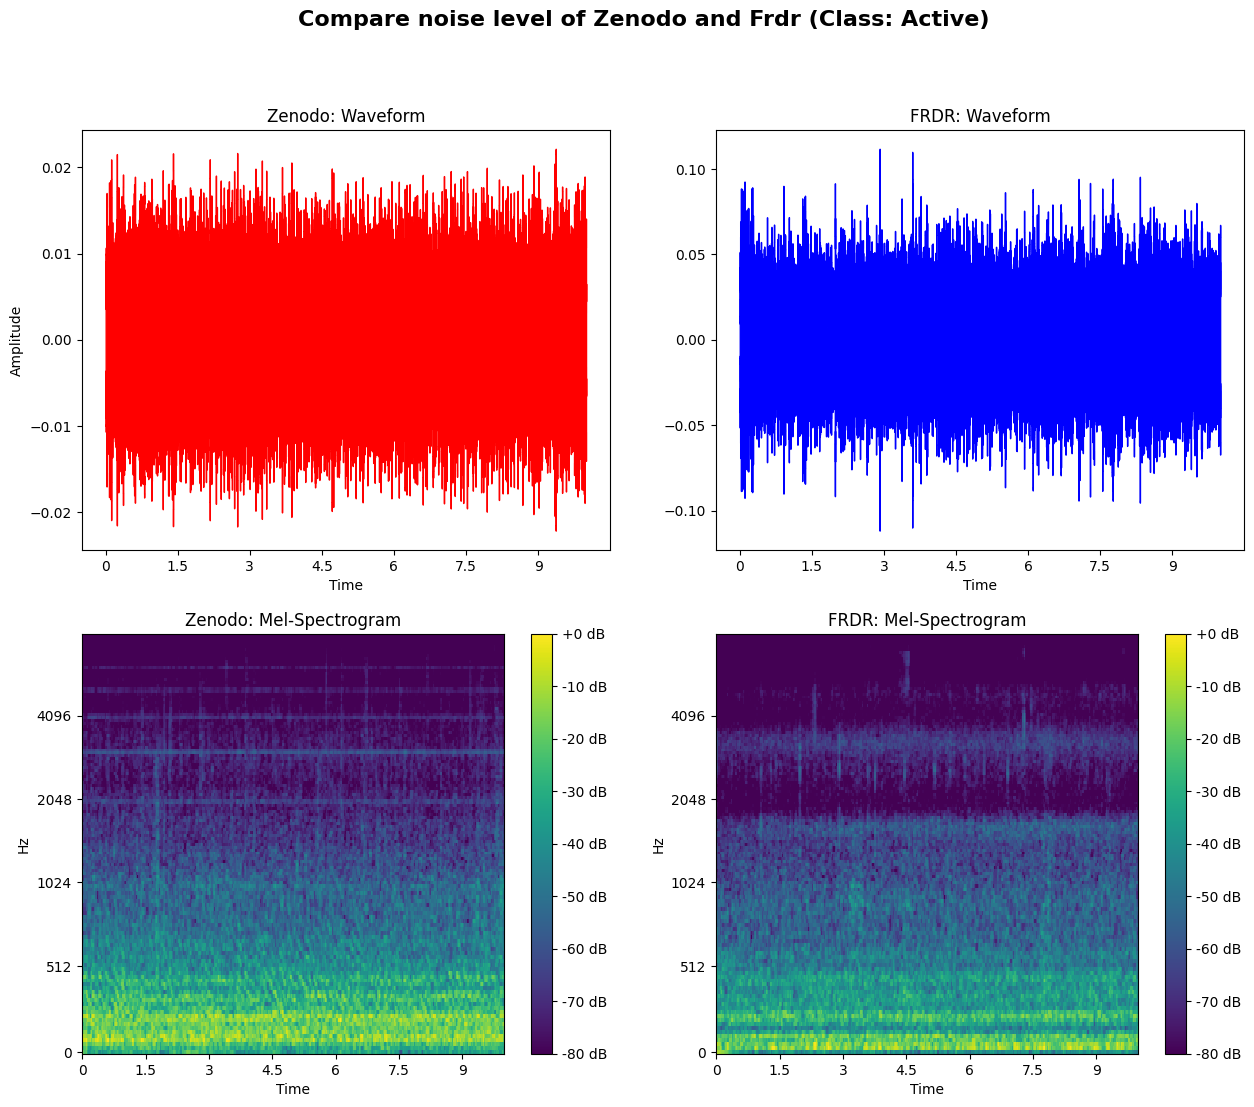

In [108]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_chunk_1\07-09-2022_14h30_HIVE-3631.wav"

sample_rate = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sample_rate)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sample_rate)

duration = 10 #(Sec)
audio_zenodo = audio_zenodo[:sample_rate * duration]
audio_frdr = audio_frdr[:sample_rate * duration]
# print(audio_frdr)

main_plot, sub_plot = plt.subplots(2, 2, figsize=(15, 12), sharex=False)
main_plot.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)", fontsize=16, fontweight='bold')
sub_plot[0, 0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sample_rate, ax=sub_plot[0, 0], color='red')
sub_plot[0, 0].set_ylabel("Amplitude")

sub_plot[0, 1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sample_rate, ax=sub_plot[0, 1], color='blue')
#=============================================================
mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo, sr=sample_rate, n_mels=128)
mel_db_zenodo = librosa.amplitude_to_db(mel_zenodo, ref=np.max)
print(mel_zenodo)
print("-"*100)
print(mel_db_zenodo)
sub_plot[1, 0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 0], cmap='viridis')
main_plot.colorbar(img1, ax=sub_plot[1,0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr, sr=sample_rate, n_mels=128)
mel_db_frdr = librosa.amplitude_to_db(mel_frdr, ref=np.max)
sub_plot[1, 1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 1], cmap='viridis')
main_plot.colorbar(img2, ax=sub_plot[1,1], format='%+2.0f dB')
#=============================================================